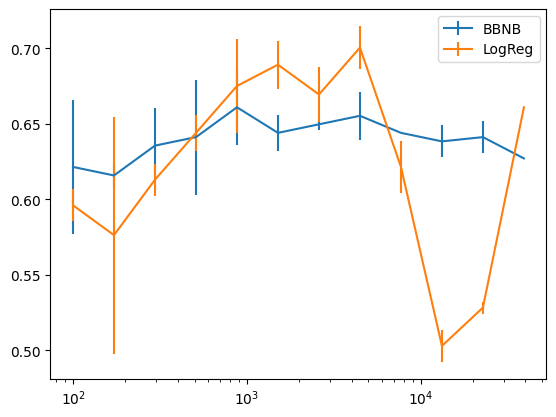

In [ ]:
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from joblib import Parallel, delayed
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from datetime import datetime
from scipy.special import betaln, gammaln, expit

# ============================================================
# NUMERICS
# ============================================================

def _clip01(x, eps=1e-6):
    return np.clip(x, eps, 1.0 - eps)

def _logit(p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p) - np.log(1 - p)

def _betabinom_logpmf(k, T, a, b):
    logC = gammaln(T + 1) - gammaln(k + 1) - gammaln(T - k + 1)
    return logC + betaln(k + a, (T - k) + b) - betaln(a, b)

def estimate_mu_per_class(X, y, a0=0.5, b0=0.5):
    y = y.astype(int)
    idx0, idx1 = y == 0, y == 1
    s0, s1 = X[idx0].sum(0), X[idx1].sum(0)
    n0, n1 = max(idx0.sum(), 1), max(idx1.sum(), 1)
    mu0 = (s0 + a0) / (n0 + a0 + b0)
    mu1 = (s1 + a0) / (n1 + a0 + b0)
    return _clip01(mu0), _clip01(mu1)

def estimate_shared_kappa(X, y, mu0, mu1):
    v0 = X[y==0].var(0, ddof=1)
    v1 = X[y==1].var(0, ddof=1)
    num = 0.5 * (mu0*(1-mu0) + mu1*(1-mu1))
    den = 0.5 * (v0 + v1)
    kappa = np.mean(num[den>0] / den[den>0]) - 1
    return float(np.clip(kappa, 2, 1e6))

# ============================================================
# Beta–Binomial Naive Bayes
# ============================================================

class BetaBinomialNaiveBayesEvidence:

    def __init__(self, T=10):
        self.T = T

    def fit(self, X, y):
        self.pi_ = y.mean()
        mu0, mu1 = estimate_mu_per_class(X, y)
        self.kappa = estimate_shared_kappa(X, y, mu0, mu1)
        self.a0, self.b0 = mu0*self.kappa, (1-mu0)*self.kappa
        self.a1, self.b1 = mu1*self.kappa, (1-mu1)*self.kappa
        return self

    def score(self, X):
        k = np.rint(self.T * X).astype(int)
        ll1 = _betabinom_logpmf(k, self.T, self.a1, self.b1)
        ll0 = _betabinom_logpmf(k, self.T, self.a0, self.b0)
        return _logit(self.pi_) + (ll1 - ll0).sum(1)

    def predict(self, X):
        return (self.score(X) > 0).astype(int)

# ============================================================
# FEATURE SWEEP
# ============================================================

def log_feature_grid(p, n_steps=12):
    return np.unique(np.round(np.logspace(2, np.log10(p), n_steps)).astype(int))

def eval_one_setting(X, y, idx, model):
    Xs = X[:, idx]
    loo = LeaveOneOut()
    acc = []

    if model == "logreg":
        Xs = StandardScaler().fit_transform(Xs)

    for tr, te in loo.split(Xs):
        Xt, Xv = Xs[tr], Xs[te]
        yt, yv = y[tr], y[te]

        if model == "logreg":
            clf = LogisticRegression(max_iter=500)
            clf.fit(Xt, yt)
            pred = clf.predict(Xv)[0]
        else:
            clf = BetaBinomialNaiveBayesEvidence()
            clf.fit(Xt, yt)
            pred = clf.predict(Xv)[0]

        acc.append(pred == yv[0])

    return np.mean(acc)

def sweep_features(X, y, model, n_resample=3, n_jobs=12):
    p = X.shape[1]
    grid = log_feature_grid(p)
    rng = np.random.default_rng(0)

    jobs = []
    for k in grid:
        for _ in range(n_resample):
            idx = rng.choice(p, k, replace=False)
            jobs.append(delayed(eval_one_setting)(X, y, idx, model))

    res = Parallel(n_jobs=n_jobs)(jobs)
    return grid, np.array(res).reshape(len(grid), n_resample)

# ============================================================
# RUN
# ============================================================

vit = np.load('/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl', allow_pickle=True)['natural_scenes']
X   = np.load('/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy').T
y   = (np.argmax(vit,1)<=397).astype(int)

grid, acc_nb = sweep_features(X,y,"bbnb")
_, acc_lr    = sweep_features(X,y,"logreg")

# ============================================================
# SAVE
# ============================================================

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
pickle.dump((grid,acc_nb,acc_lr), open(f"sweep_{ts}.pkl","wb"))

# ============================================================
# PLOT
# ============================================================

plt.errorbar(grid, acc_nb.mean(1), yerr=acc_nb.std(1), label="BBNB")
plt.errorbar(grid, acc_lr.mean(1), yerr=acc_lr.std(1), label="LogReg")
plt.xscale("log")
plt.legend()
plt.show()


In [ ]:
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from joblib import Parallel, delayed
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from datetime import datetime
from scipy.special import betaln, gammaln, expit

# ============================================================
# NUMERICS
# ============================================================

def _clip01(x, eps=1e-6):
    return np.clip(x, eps, 1.0 - eps)

def _logit(p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p) - np.log(1 - p)

def _betabinom_logpmf(k, T, a, b):
    logC = gammaln(T + 1) - gammaln(k + 1) - gammaln(T - k + 1)
    return logC + betaln(k + a, (T - k) + b) - betaln(a, b)

def estimate_mu_per_class(X, y, a0=0.5, b0=0.5):
    y = y.astype(int)
    idx0, idx1 = y == 0, y == 1
    s0, s1 = X[idx0].sum(0), X[idx1].sum(0)
    n0, n1 = max(idx0.sum(), 1), max(idx1.sum(), 1)
    mu0 = (s0 + a0) / (n0 + a0 + b0)
    mu1 = (s1 + a0) / (n1 + a0 + b0)
    return _clip01(mu0), _clip01(mu1)

def estimate_shared_kappa(X, y, mu0, mu1):
    v0 = X[y==0].var(0, ddof=1)
    v1 = X[y==1].var(0, ddof=1)
    num = 0.5 * (mu0*(1-mu0) + mu1*(1-mu1))
    den = 0.5 * (v0 + v1)
    kappa = np.mean(num[den>0] / den[den>0]) - 1
    return float(np.clip(kappa, 2, 1e6))

# ============================================================
# Beta–Binomial Naive Bayes
# ============================================================

class BetaBinomialNaiveBayesEvidence:

    def __init__(self, T=10):
        self.T = T

    def fit(self, X, y):
        self.pi_ = y.mean()
        mu0, mu1 = estimate_mu_per_class(X, y)
        self.kappa = estimate_shared_kappa(X, y, mu0, mu1)
        self.a0, self.b0 = mu0*self.kappa, (1-mu0)*self.kappa
        self.a1, self.b1 = mu1*self.kappa, (1-mu1)*self.kappa
        return self

    def score(self, X):
        k = np.rint(self.T * X).astype(int)
        ll1 = _betabinom_logpmf(k, self.T, self.a1, self.b1)
        ll0 = _betabinom_logpmf(k, self.T, self.a0, self.b0)
        return _logit(self.pi_) + (ll1 - ll0).sum(1)

    def predict(self, X):
        return (self.score(X) > 0).astype(int)

# ============================================================
# FEATURE SWEEP
# ============================================================

def log_feature_grid(p, n_steps=12):
    return np.unique(np.round(np.logspace(2, np.log10(p), n_steps)).astype(int))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from joblib import Parallel, delayed
from datetime import datetime
import pickle

# ============================================================
# SAFE BETABINOMIAL (imports inside worker!)
# ============================================================

def eval_one_setting(X, y, idx, model):

    import numpy as np
    from sklearn.model_selection import LeaveOneOut
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from scipy.special import gammaln, betaln

    def betabinom_logpmf(k, T, a, b):
        logC = gammaln(T + 1) - gammaln(k + 1) - gammaln(T - k + 1)
        return logC + betaln(k + a, (T - k) + b) - betaln(a, b)

    Xs = X[:, idx]
    loo = LeaveOneOut()
    acc = []

    for tr, te in loo.split(Xs):
        Xt, Xv = Xs[tr], Xs[te]
        yt, yv = y[tr], y[te]

        if model == "logreg":
            clf = make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    penalty="l2",
                    solver="saga",
                    C=1.0,
                    max_iter=5000,
                    tol=1e-3,
                    random_state=0
                )
            )
            clf.fit(Xt, yt)
            pred = clf.predict(Xv)[0]

        else:
            T = 10
            mu0 = Xt[yt == 0].mean(0)
            mu1 = Xt[yt == 1].mean(0)
            kappa = 50

            a0, b0 = mu0 * kappa, (1 - mu0) * kappa
            a1, b1 = mu1 * kappa, (1 - mu1) * kappa

            k = np.rint(T * Xv).astype(int)
            s = (betabinom_logpmf(k, T, a1, b1) -
                 betabinom_logpmf(k, T, a0, b0)).sum()

            pred = int(s > 0)

        acc.append(pred == yv[0])

    return np.mean(acc)

# ============================================================
# FEATURE GRID
# ============================================================

def log_feature_grid(p, n_steps=12):
    return np.unique(np.round(np.logspace(2, np.log10(p), n_steps)).astype(int))

def sweep_features(X, y, model, n_resample=30, n_jobs=12):
    p = X.shape[1]
    grid = log_feature_grid(p)

    def run_one(k, rep):
        rng = np.random.default_rng(10000 * k + rep)
        idx = rng.choice(p, size=k, replace=False)
        acc = eval_one_setting(X, y, idx, model)
        return k, rep, acc

    jobs = [delayed(run_one)(k, r) for k in grid for r in range(n_resample)]
    results = Parallel(n_jobs=n_jobs, verbose=10)(jobs)
    return results

def aggregate(res):
    df = pd.DataFrame(res, columns=["k", "rep", "acc"])
    g = df.groupby("k")["acc"]
    out = g.agg(["mean", "std", "count"]).reset_index()
    out["se"] = out["std"] / np.sqrt(out["count"])
    return out

# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    vit = np.load('/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl',
                  allow_pickle=True)['natural_scenes']
    X = np.load('/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy').T
    y = (np.argmax(vit, axis=1) <= 397).astype(int)

    print("Images:", X.shape[0], "Neurons:", X.shape[1])

    res_nb = sweep_features(X, y, "bbnb")
    res_lr = sweep_features(X, y, "logreg")

    df_nb = aggregate(res_nb)
    df_lr = aggregate(res_lr)

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    pickle.dump((res_nb, res_lr), open(f"sweep_raw_{ts}.pkl", "wb"))
    df_nb.to_csv(f"sweep_bbnb_{ts}.csv", index=False)
    df_lr.to_csv(f"sweep_logreg_{ts}.csv", index=False)

    plt.errorbar(df_nb.k, df_nb["mean"], yerr=df_nb["se"], label="BBNB")
    plt.errorbar(df_lr.k, df_lr["mean"], yerr=df_lr["se"], label="LogReg")
    plt.xscale("log")
    plt.xlabel("# neurons")
    plt.ylabel("LOO accuracy")
    plt.legend()
    plt.title("Bias–Variance Geometry of Neural Decoders")
    plt.savefig(f"bias_variance_{ts}.png", dpi=200)
    plt.show()


Loading:
/home/maria/ProjectionSort/betabinomialmodel/sweep_raw_20260106_160048.pkl
/home/maria/ProjectionSort/betabinomialmodel/sweep_bbnb_20260106_160048.csv
/home/maria/ProjectionSort/betabinomialmodel/sweep_logreg_20260106_160048.csv


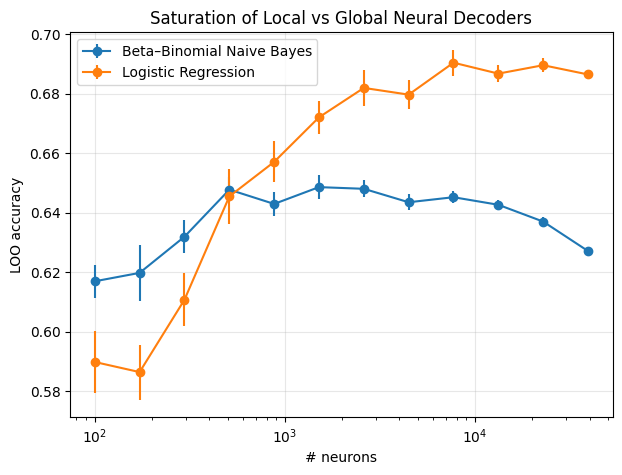

In [ ]:
import sys, pickle, pandas as pd, matplotlib.pyplot as plt
#https://chatgpt.com/g/g-p-676c80353b988191819d6d02aca806d6-msc-thesis/c/695cdade-01bc-8327-a725-e12cbd94adba

# ============================================================
# SET FILES HERE IF RUNNING IN NOTEBOOK
# ============================================================

RAW_PATH    = "/home/maria/ProjectionSort/betabinomialmodel/sweep_raw_20260106_160048.pkl"
BBNB_PATH   = "/home/maria/ProjectionSort/betabinomialmodel/sweep_bbnb_20260106_160048.csv"
LOGREG_PATH = "/home/maria/ProjectionSort/betabinomialmodel/sweep_logreg_20260106_160048.csv"

# ============================================================
# READ CLI ARGS IF PRESENT
# ============================================================

if len(sys.argv) >= 4:
    raw_path, bbnb_path, logreg_path = sys.argv[1:4]
else:
    raw_path, bbnb_path, logreg_path = RAW_PATH, BBNB_PATH, LOGREG_PATH

print("Loading:")
print(raw_path)
print(bbnb_path)
print(logreg_path)

# ============================================================
# LOAD
# ============================================================

with open(raw_path, "rb") as f:
    res_nb, res_lr = pickle.load(f)

df_nb = pd.read_csv(bbnb_path)
df_lr = pd.read_csv(logreg_path)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(7,5))
plt.errorbar(df_nb.k, df_nb["mean"], yerr=df_nb["se"],
             marker="o", label="Beta–Binomial Naive Bayes")
plt.errorbar(df_lr.k, df_lr["mean"], yerr=df_lr["se"],
             marker="o", label="Logistic Regression")

plt.xscale("log")
plt.xlabel("# neurons")
plt.ylabel("LOO accuracy")
plt.title("Saturation of Local vs Global Neural Decoders")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [11]:
print("Input dimensionalities (number of neurons):")
for k in df_nb["k"].values:
    print(int(k))


Input dimensionalities (number of neurons):
100
172
296
510
877
1509
2598
4470
7693
13239
22784
39209


In [12]:
ks = df_nb["k"].values
print("Ratios between successive k:")
print(np.round(ks[1:] / ks[:-1], 2))

Ratios between successive k:
[1.72 1.72 1.72 1.72 1.72 1.72 1.72 1.72 1.72 1.72 1.72]
